In [8]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt

print("loading dataset...")

# run divider.py first to get the simplified labels
labeled_dataset = pd.read_csv('data/labeled_processed.csv')

print("dataset loaded!")

train, test = train_test_split(
    labeled_dataset,
    test_size=0.2,
    random_state=1,
    stratify=labeled_dataset['event_type']
)

fields_to_drop = [
    'sample', 'file_name', 'ML_1', 'ML_1_1', 'ML_1_1_1', 'ML_1_2','ML_2','ML_2_1_1','ML_2_1_2','ML_2_1_3','ML_2_2','ML_2_3',
    'ML_2_3_1','ML_2_4_1','ML_2_4_2','ML_2_5_1','ML_2_6','ML_2_7_1','ML_2_7_2','ML_3','ML_3_1','ML_3_2','ML_3_3','ML_3_4',
    'ML_3_5', 'event_type']

train_features = train.drop(fields_to_drop, axis=1)
train_labels = train['event_type']

test_features = test.drop(fields_to_drop, axis=1)
test_labels = test['event_type']


loading dataset...
dataset loaded!


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 1.2012976	test: 1.2012118	best: 1.2012118 (0)	total: 2.04s	remaining: 2m 31s
1:	learn: 0.9706739	test: 0.9705679	best: 0.9705679 (1)	total: 3.98s	remaining: 2m 25s
2:	learn: 0.8416882	test: 0.8414888	best: 0.8414888 (2)	total: 6.34s	remaining: 2m 32s
3:	learn: 0.7562591	test: 0.7565204	best: 0.7565204 (3)	total: 8.69s	remaining: 2m 34s
4:	learn: 0.6972885	test: 0.6975373	best: 0.6975373 (4)	total: 10.6s	remaining: 2m 28s
5:	learn: 0.6570431	test: 0.6572402	best: 0.6572402 (5)	total: 12.5s	remaining: 2m 24s
6:	learn: 0.6225939	test: 0.6225544	best: 0.6225544 (6)	total: 14.4s	remaining: 2m 19s
7:	learn: 0.5904471	test: 0.5904613	best: 0.5904613 (7)	total: 16.4s	remaining: 2m 16s
8:	learn: 0.5617784	test: 0.5618311	best: 0.5618311 (8)	total: 18.2s	remaining: 2m 13s
9:	learn: 0.5428641	test: 0.5430716	best: 0.5430716 (9)	total: 20.1s	remaining: 2m 10s
10:	learn: 0.5241191	test: 0.5242859	best: 0.5242859 (10)	total: 22.2s	remaining: 2m 9s
11:	learn: 0.5069531	test: 0.5070861	best:

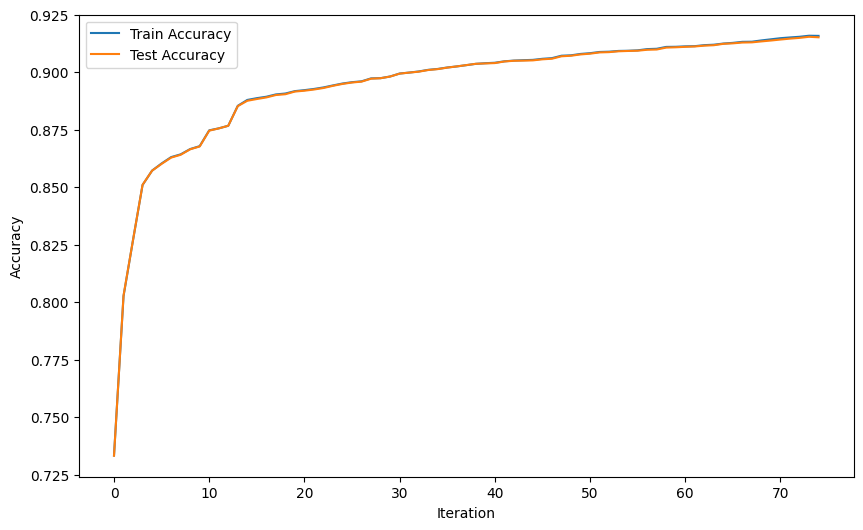

Best Train Accuracy: 0.9158511116700585
Best Test Accuracy: 0.9152356344179453


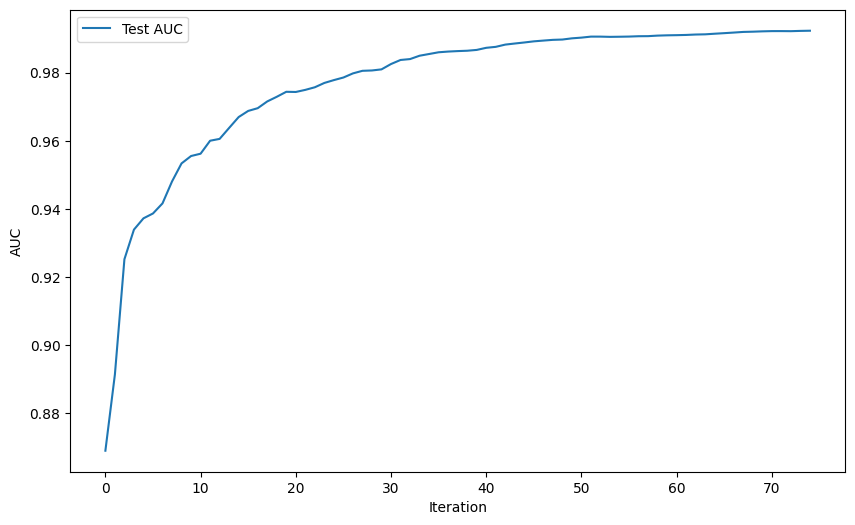

Best Test AUC: 0.9922924561707142


In [9]:
classifier = CatBoostClassifier(
    iterations=75,
    random_seed=2,
    learning_rate=0.2,
    custom_loss=['AUC', 'Accuracy']
)

classifier.fit(
    train_features, train_labels,
    eval_set=(test_features, test_labels),
    verbose=1,
    plot=True
)

plt.figure(figsize=(10, 6))
plt.plot(classifier.evals_result_['learn']['Accuracy'], label='Train Accuracy')
plt.plot(classifier.evals_result_['validation']['Accuracy'], label='Test Accuracy')
plt.xlabel('Iteration')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
print(f"Best Train Accuracy: {classifier.evals_result_['learn']['Accuracy'][-1]}")
print(f"Best Test Accuracy: {classifier.evals_result_['validation']['Accuracy'][-1]}")

plt.figure(figsize=(10, 6))
plt.plot(classifier.evals_result_['validation']['AUC:type=Mu'], label='Test AUC')
plt.xlabel('Iteration')
plt.ylabel('AUC')
plt.legend()
plt.show()
print(f"Best Test AUC: {classifier.evals_result_['validation']['AUC:type=Mu'][-1]}")

In [6]:
#classifier.save_model("trained_osc_grid_catboost", format="cbm")